In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [127]:
df = pd.read_excel(r'Employee Promotion.xlsx')

In [128]:
pd.get_option('display.max_columns',None)

20

In [129]:
df

,Age,Salary,Experience,Hours_Per_Week,Projects_Handled,Performance_Score,Gender,Department,Education,Work_Mode,Promotion
0,50.0,NaN,26.0,54.396742,1.0,60.152985,Female,Marketing,PG,Remote,No
1,NaN,39586.481750,13.0,41.298858,11.0,68.151239,Male,Sales,UG,Office,No
2,NaN,30008.977466,29.0,50.543684,2.0,54.588150,Male,Marketing,PG,Remote,No
3,37.0,45943.385466,20.0,33.327514,7.0,68.678565,NaN,Marketing,PG,Office,No
4,26.0,46666.916822,15.0,35.821476,5.0,48.108924,Female,HR,PhD,Remote,No
...,...,...,...,...,...,...,...,...,...,...,...
2005,36.0,82712.923264,22.0,47.849331,9.0,65.846203,Male,Sales,PhD,Remote,No
2006,41.0,39711.035527,7.0,48.246886,11.0,50.338899,Male,Marketing,PG,Hybrid,No
2007,25.0,78737.763083,22.0,41.574229,6.0,66.543881,Female,Marketing,PhD,Remote,No
2008,38.0,NaN,17.0,NaN,1.0,54.792222,Female,Sales,PhD,Remote,NaN


In [130]:
df.shape

(2010, 11)

In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2010 entries, 0 to 2009
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                1910 non-null   float64
 1   Salary             1910 non-null   float64
 2   Experience         1910 non-null   float64
 3   Hours_Per_Week     1911 non-null   float64
 4   Projects_Handled   1909 non-null   float64
 5   Performance_Score  1910 non-null   float64
 6   Gender             1909 non-null   object 
 7   Department         1909 non-null   object 
 8   Education          1910 non-null   object 
 9   Work_Mode          1909 non-null   object 
 10  Promotion          1909 non-null   object 
dtypes: float64(6), object(5)
memory usage: 172.9+ KB


In [132]:
df.describe()

,Age,Salary,Experience,Hours_Per_Week,Projects_Handled,Performance_Score
count,1910.000000,1910.000000,1910.000000,1911.000000,1909.000000,1910.000000
mean,41.376963,57583.577728,14.881152,46.106678,7.529073,69.504760
std,13.514918,26526.089335,8.533422,13.136412,3.973288,15.090505
min,18.000000,-5962.647707,0.000000,12.037470,1.000000,14.550671
25%,30.000000,43538.477174,8.000000,38.538444,4.000000,59.601134
50%,42.000000,56403.073261,15.000000,45.218813,8.000000,69.835305
75%,53.000000,68281.895986,22.000000,52.177795,11.000000,79.358640
max,64.000000,357227.777089,29.000000,120.000000,14.000000,121.212805


In [134]:
df.duplicated().sum()

np.int64(10)

In [135]:
df.drop_duplicates(keep='first', inplace=True)

In [136]:
df.duplicated().sum()

np.int64(0)

In [137]:
df.isna().sum()

Age                  100
Salary               100
Experience           100
Hours_Per_Week        99
Projects_Handled     100
Performance_Score    100
Gender               100
Department           100
Education            100
Work_Mode            100
Promotion            100
dtype: int64

In [138]:
for col in df.select_dtypes('float64').columns:
    df[col] = df[col].fillna(df[col].median())

In [139]:
for col in df.select_dtypes('object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [140]:
df.isna().sum()

Age                  0
Salary               0
Experience           0
Hours_Per_Week       0
Projects_Handled     0
Performance_Score    0
Gender               0
Department           0
Education            0
Work_Mode            0
Promotion            0
dtype: int64

In [141]:
df.duplicated().sum()

np.int64(0)

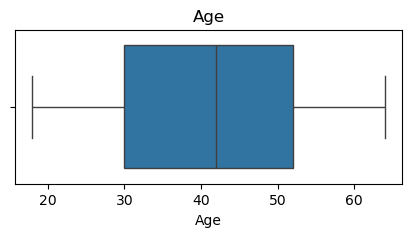

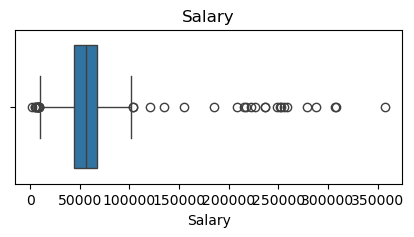

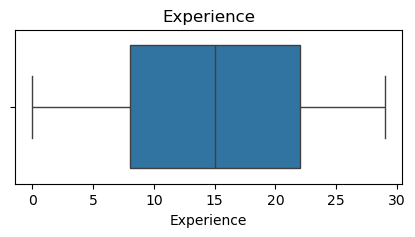

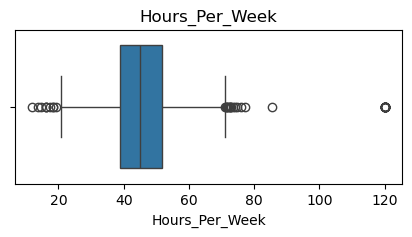

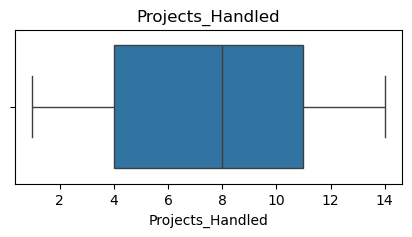

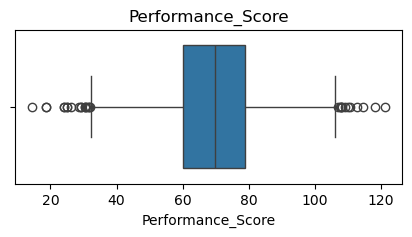

In [142]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [143]:
num_col = df.select_dtypes("number")
corr_df  = num_col.corr()
corr_df.style.background_gradient("coolwarm")

,Age,Salary,Experience,Hours_Per_Week,Projects_Handled,Performance_Score
Age,1.000000,-0.022108,-0.000584,0.000126,0.002292,0.018013
Salary,-0.022108,1.000000,0.013078,0.416755,-0.003615,0.013869
Experience,-0.000584,0.013078,1.000000,-0.020486,-0.008954,-0.032585
Hours_Per_Week,0.000126,0.416755,-0.020486,1.000000,-0.023972,0.010688
Projects_Handled,0.002292,-0.003615,-0.008954,-0.023972,1.000000,0.011957
Performance_Score,0.018013,0.013869,-0.032585,0.010688,0.011957,1.000000


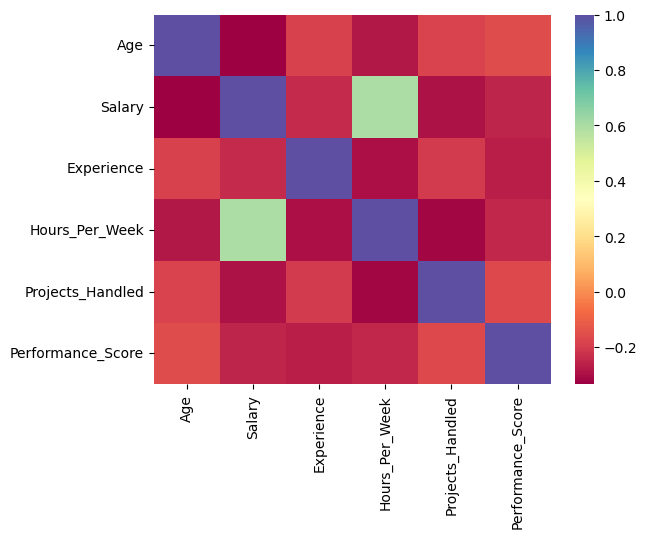

In [144]:
corr = corr_df.corr()
sns.heatmap(corr, annot=False, cmap='Spectral');

A company wants to identify which employees are likely to get promoted based on their work performance, experience, working hours, projects handled, salary, education level, and other employee-related factors.

The HR department currently evaluates promotions manually, which is time-consuming and may lead to biased decisions. To improve the efficiency and accuracy of the promotion process, the company wants to build a Machine Learning Classification Model that can predict whether an employee will be promoted or not.

In [145]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [146]:
label = LabelEncoder()
cat_cols = ['Gender', 'Department', 'Education', 'Work_Mode', 'Promotion']
for col in cat_cols:
    df[col] = df[col].astype(str)
    df[col] = label.fit_transform(df[col])

In [147]:
x = df.drop(columns=['Promotion'])
y = df['Promotion']

In [148]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [149]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, train_size=0.80, random_state=42)

In [150]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()

In [151]:
lor.fit(x_train, y_train)

LogisticRegression()

In [152]:
y_pred = lor.predict(x_test)

In [153]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, f1_score, auc

In [154]:
accuracy_score(y_pred, y_test)

0.8975

In [155]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.97      0.92      0.94       362
           1       0.47      0.71      0.57        38

    accuracy                           0.90       400
   macro avg       0.72      0.81      0.76       400
weighted avg       0.92      0.90      0.91       400



In [156]:
from sklearn.neighbors import KNeighborsClassifier as KNN
knn = KNN()

In [157]:
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [158]:
y_predk = knn.predict(x_test)

In [159]:
accuracy_score(y_predk, y_test)

0.8925

In [160]:
print(classification_report(y_predk, y_test))

              precision    recall  f1-score   support

           0       0.98      0.91      0.94       370
           1       0.39      0.73      0.51        30

    accuracy                           0.89       400
   macro avg       0.68      0.82      0.72       400
weighted avg       0.93      0.89      0.91       400



In [161]:
from sklearn.svm import SVC

In [162]:
svc = SVC()

In [163]:
svc.fit(x_train, y_train)

SVC()

In [164]:
y_preds = svc.predict(x_test)

In [165]:
accuracy_score(y_preds, y_test)

0.915

In [166]:
print(classification_report(y_preds, y_test))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95       359
           1       0.56      0.78      0.65        41

    accuracy                           0.92       400
   macro avg       0.77      0.86      0.80       400
weighted avg       0.93      0.92      0.92       400

